In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from nltk.translate.bleu_score import corpus_bleu
import nltk
nltk.download('punkt')

from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/image_caption_generator'
print("Setup complete!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Mounted at /content/drive
Setup complete!


In [2]:
# Load tokenizer
with open(os.path.join(save_path, 'tokenizer.pkl'), 'rb') as f:
    tokenizer = pickle.load(f)

# Load captions
df = pd.read_csv(os.path.join(save_path, 'cleaned_captions.csv'))

# Load trained model
print("Loading trained model...")
model = load_model(os.path.join(save_path, 'best_model.keras'))
print("Model loaded!")

# Key parameters
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(c.split()) for c in df['caption'].tolist())

# Create index to word mapping
index_to_word = {v: k for k, v in tokenizer.word_index.items()}

print(f"Vocab size: {vocab_size}")
print(f"Max length: {max_length}")

Loading trained model...
Model loaded!
Vocab size: 8781
Max length: 37


In [3]:
print("Loading InceptionV3...")
base_model = InceptionV3(weights='imagenet')
feature_extractor = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model.layers[-2].output
)
print("Feature extractor ready!")

# Function to extract features from image
def extract_features(image_path):
    img = load_img(image_path, target_size=(299, 299))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    feature = feature_extractor.predict(img, verbose=0)
    return feature

Loading InceptionV3...
96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Feature extractor ready!


In [4]:
def generate_caption(image_path, model, tokenizer,
                     max_length, index_to_word):
    # Extract image features
    feature = extract_features(image_path)

    # Start with startseq token
    caption = 'startseq'

    for _ in range(max_length):
        # Tokenize current caption
        seq = tokenizer.texts_to_sequences([caption])[0]
        seq = pad_sequences([seq], maxlen=max_length)

        # Predict next word
        pred = model.predict(
            [feature, seq], verbose=0
        )
        pred_idx = np.argmax(pred)

        # Convert index to word
        word = index_to_word.get(pred_idx, None)

        # Stop if endseq or unknown
        if word is None or word == 'endseq':
            break

        caption += ' ' + word

    # Clean up caption
    caption = caption.replace('startseq', '').strip()
    return caption

print("Caption generator function ready!")

Caption generator function ready!


In [5]:
# Download Flickr8k dataset for test images
from google.colab import files
import os

!pip install kaggle -q
os.makedirs('/root/.kaggle', exist_ok=True)

# Upload kaggle.json
files.upload()
import shutil
shutil.move('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

!kaggle datasets download -d adityajn105/flickr8k -q
!unzip -q flickr8k.zip -d /content/flickr8k

print("Test images ready!")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
Test images ready!


Generating captions for test images...
Image 1: 832128857_1390386ea6.jpg
Generated: a little girl in a pink shirt is jumping on a swing
----------------------------------------
Image 2: 510510783_b2cf5d57bb.jpg
Generated: a boy in a red jacket is jumping off a rock wall
----------------------------------------
Image 3: 942399470_6132d3e5d2.jpg
Generated: a man in a red shirt is standing on a sidewalk with a mohawk
----------------------------------------
Image 4: 3541491057_61a49588d9.jpg
Generated: a dog runs through the grass
----------------------------------------
Image 5: 460350019_af60511a3b.jpg
Generated: a dog runs through the snow
----------------------------------------


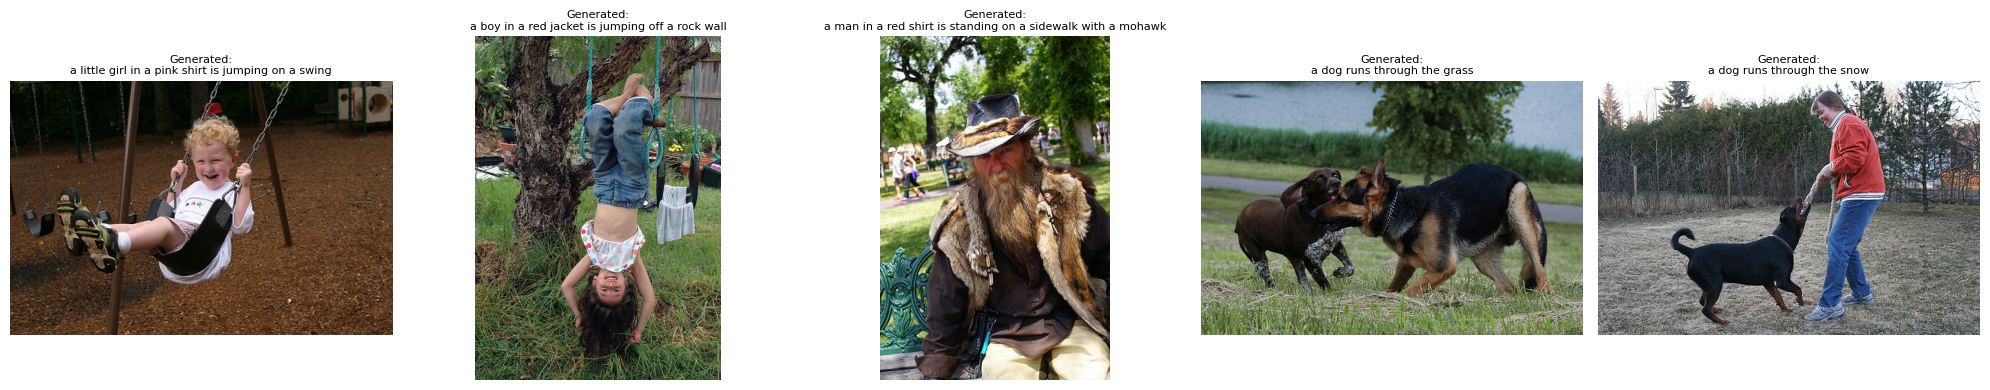

Done!


In [6]:
# Get test images
image_folder = '/content/flickr8k/Images'

# Group captions
image_captions = {}
for _, row in df.iterrows():
    img = row['image']
    cap = row['caption']
    if img not in image_captions:
        image_captions[img] = []
    image_captions[img].append(cap)

all_images = list(image_captions.keys())
test_images = all_images[6000:]

# Generate captions for 5 random test images
import random
sample_images = random.sample(test_images, 5)

print("Generating captions for test images...")
print("=" * 60)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(image_folder, img_name)

    # Generate caption
    generated = generate_caption(
        img_path, model, tokenizer,
        max_length, index_to_word
    )

    # Show image
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(
        f"Generated:\n{generated}",
        fontsize=8, wrap=True
    )

    print(f"Image {i+1}: {img_name}")
    print(f"Generated: {generated}")
    print("-" * 40)

plt.tight_layout()
plt.savefig('sample_captions.png', bbox_inches='tight')
plt.show()
print("Done!")

In [7]:
print("Calculating BLEU scores...")
print("This takes 2-3 minutes...")

actual_captions = []
predicted_captions = []

# Evaluate on 200 test images
eval_images = test_images[:200]

for img_name in eval_images:
    img_path = os.path.join(image_folder, img_name)

    if not os.path.exists(img_path):
        continue

    # Get actual captions
    actual = [cap.split() for cap in image_captions[img_name]]

    # Generate predicted caption
    predicted = generate_caption(
        img_path, model, tokenizer,
        max_length, index_to_word
    ).split()

    actual_captions.append(actual)
    predicted_captions.append(predicted)

# Calculate BLEU scores
bleu1 = corpus_bleu(
    actual_captions, predicted_captions,
    weights=(1.0, 0, 0, 0)
)
bleu2 = corpus_bleu(
    actual_captions, predicted_captions,
    weights=(0.5, 0.5, 0, 0)
)
bleu3 = corpus_bleu(
    actual_captions, predicted_captions,
    weights=(0.33, 0.33, 0.33, 0)
)
bleu4 = corpus_bleu(
    actual_captions, predicted_captions,
    weights=(0.25, 0.25, 0.25, 0.25)
)

print(f"\n{'='*40}")
print(f"BLEU Score Results:")
print(f"{'='*40}")
print(f"BLEU-1: {bleu1:.4f} ({bleu1*100:.1f}%)")
print(f"BLEU-2: {bleu2:.4f} ({bleu2*100:.1f}%)")
print(f"BLEU-3: {bleu3:.4f} ({bleu3*100:.1f}%)")
print(f"BLEU-4: {bleu4:.4f} ({bleu4*100:.1f}%)")
print(f"{'='*40}")
print(f"\nBLEU-1 above 50% = Good model!")
print(f"BLEU-1 above 60% = Great model!")

Calculating BLEU scores...
This takes 2-3 minutes...

BLEU Score Results:
BLEU-1: 0.4958 (49.6%)
BLEU-2: 0.3158 (31.6%)
BLEU-3: 0.1805 (18.0%)
BLEU-4: 0.1032 (10.3%)

BLEU-1 above 50% = Good model!
BLEU-1 above 60% = Great model!


In [8]:
import json
results = {
    'bleu1': bleu1,
    'bleu2': bleu2,
    'bleu3': bleu3,
    'bleu4': bleu4,
    'test_images_evaluated': len(predicted_captions)
}

results_path = os.path.join(save_path, 'evaluation_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

print("Results saved to Google Drive!")
print(f"Images evaluated: {len(predicted_captions)}")
print(f"BLEU-1 Score: {bleu1*100:.1f}%")

Results saved to Google Drive!
Images evaluated: 200
BLEU-1 Score: 49.6%
